In [1]:
%load_ext autoreload
%autoreload 2

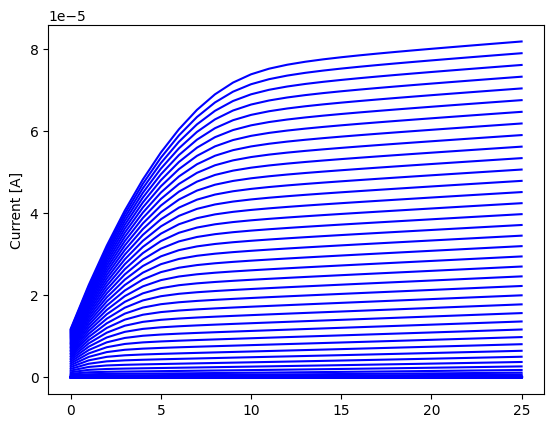

100%|██████████| 20000/20000 [10:53<00:00, 30.62it/s]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import logging
from tqdm import tqdm
from src.get_first_device import get_first_device
from src.get_seperated_curves import get_seperated_curves
from src.plot_curves import plot_curves
from src.encoder import Encoder
from src.decoder import Decoder
from src.set_logger import set_logger
from src.get_reconstruction_loss import get_reconstruction_loss
from src.mlp import Mlp
from src.pretrain_latent_diffusion import pretrain_latent_diffusion
from src.visualize_0 import visualize_0
from src.get_20_devices import get_20_devices
from src.torch_dataset import TorchDataset

CSV_FILE = "nmos_130nm_gaussian_l_vth_rds_50_devs_into_subth.csv"
SEP = " "
DEVICE_DIM = 1378
CURRENT_COL = 3
VOLTAGE_0_DIM = 53
VOLTAGE_1_DIM = 26
LEARNING_RATE = 2e-4
EPOCHS = 20_000
LOGGING_FILE = "logs.log"
LOGGER_LEVEL = logging.INFO

dataframe = pd.read_csv(CSV_FILE, sep=SEP, header=None)
logger = set_logger(LOGGING_FILE, LOGGER_LEVEL)
torch_dataset = TorchDataset(
    dataframe,
    CURRENT_COL,
    DEVICE_DIM
)
train_loader = torch.utils.data.DataLoader(
    torch_dataset, batch_size=5
)

first_device_data = get_first_device(dataframe, DEVICE_DIM, CURRENT_COL)
separated_curves = get_seperated_curves(first_device_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
device = "cuda"

encoder = Encoder().to(device)
decoder = Decoder().to(device)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LEARNING_RATE
)

first_device_data_tensor = torch.tensor(first_device_data, dtype=torch.float32)
mse_loss = torch.nn.MSELoss()

devices_20_data = get_20_devices(dataframe, DEVICE_DIM, CURRENT_COL) 
devices_20_data_tensor = torch.tensor(devices_20_data, dtype=torch.float32)

loss_list = []
for epoch in tqdm(range(EPOCHS)):
    for _, dev_data in enumerate(train_loader):
    # for dev in devices_20_data_tensor:
        device_data = dev_data.to(torch.float32)
        device_data = device_data.to(device)
        latent_data = encoder(device_data)
        output_data = decoder(latent_data)

        loss = get_reconstruction_loss(output_data, device_data)
        rec_loss = loss
        
        mean_loss = torch.mean(latent_data.pow(2))
        std = torch.std(latent_data, dim=0)
        std_loss = torch.mean((std - 1) ** 2)

        loss = loss + mean_loss * 1 + std_loss * 1
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    loss_list.append(loss.item())

    if epoch % 1000 == 0:
        plt.plot(loss_list[-1000:])
        plt.title(f"Epoch {epoch}")
        plt.savefig(f"loss_epoch{epoch}.png")
        plt.close()

    if epoch % 100 == 0:
        logger.info(f"EPOCH: {epoch} LOSS: {rec_loss.item()}")
        logger.info(f"EPOCH: {epoch} MEAN_L: {mean_loss.item()}")
        logger.info(f"EPOCH: {epoch} STD_L: {std_loss.item()}")

In [3]:
feature_0_list = []
feature_10_list = []

samples_list = []
for i in range(30):
    samples_list.append([])

for i in range(len(torch_dataset)):
    features_vector_np = torch_dataset[i]
    features_vector_tensor = torch.tensor(features_vector_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        latent_tensor = encoder(features_vector_tensor)
    latent_numpy =  latent_tensor.cpu().numpy()

    for index in range(len(latent_numpy)):
        samples_list[index].append(latent_numpy[index])

# plt.plot(feature_0_list)
# plt.show()
# plt.plot(feature_10_list)
var_list = []
mean_list = []

var_0_count = 0

for i in range(len(samples_list)):
    var_val = np.var(samples_list[i])
    var_list.append(var_val)
    mean_list.append(np.mean(samples_list[i]))

    if np.isclose(var_val, 0.0):
        var_0_count += 1

for i in range(len(samples_list)):
    print(var_list[i])

0.0
0.0
0.104241505
0.10173222
0.0
0.10397762
0.10759929
0.11100479
0.0
0.10439949
0.09726293
0.0
0.10407789
0.099737816
0.10650919
0.10467696
0.0
0.10581228
0.09682213
0.10273899
0.096775636
0.0
0.10623505
0.108954884
0.10779888
0.10247333
0.08939349
0.099674486
0.08031096
0.07865187


In [4]:
for i in range(len(samples_list)):
    print(mean_list[i])

0.0
0.0
0.29860532
0.28244528
0.0
0.32195842
0.31120965
0.2592737
0.0
0.3243442
0.2690677
0.0
0.3092232
0.28412694
0.28398365
0.2953492
0.0
0.2465402
0.2929316
0.28392372
0.29368645
0.0
0.31062508
0.26970017
0.30221075
0.30107707
0.2741826
0.2864769
0.26109755
0.2704314


In [5]:
var_0_count

7

In [6]:
for i in range(len(samples_list)):
    print(f"VAR: {var_list[i]}  MEAN: {mean_list[i]}")

VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.1042415052652359  MEAN: 0.2986053228378296
VAR: 0.10173221677541733  MEAN: 0.2824452817440033
VAR: 0.0  MEAN: 0.0
VAR: 0.10397762060165405  MEAN: 0.32195842266082764
VAR: 0.10759928822517395  MEAN: 0.31120964884757996
VAR: 0.1110047921538353  MEAN: 0.2592737078666687
VAR: 0.0  MEAN: 0.0
VAR: 0.10439948737621307  MEAN: 0.3243441879749298
VAR: 0.0972629263997078  MEAN: 0.2690677046775818
VAR: 0.0  MEAN: 0.0
VAR: 0.10407789051532745  MEAN: 0.3092232048511505
VAR: 0.09973781555891037  MEAN: 0.2841269373893738
VAR: 0.10650918632745743  MEAN: 0.28398364782333374
VAR: 0.10467696189880371  MEAN: 0.29534921050071716
VAR: 0.0  MEAN: 0.0
VAR: 0.10581228137016296  MEAN: 0.24654020369052887
VAR: 0.09682212769985199  MEAN: 0.29293158650398254
VAR: 0.10273899137973785  MEAN: 0.2839237153530121
VAR: 0.09677563607692719  MEAN: 0.2936864495277405
VAR: 0.0  MEAN: 0.0
VAR: 0.10623504966497421  MEAN: 0.3106250762939453
VAR: 0.10895488411188126  MEAN: 0.2697001

tensor([1.9893e-12, 3.4617e-12, 9.0675e-12,  ..., 7.6184e-05, 7.9046e-05,
        8.1907e-05], device='cuda:0')


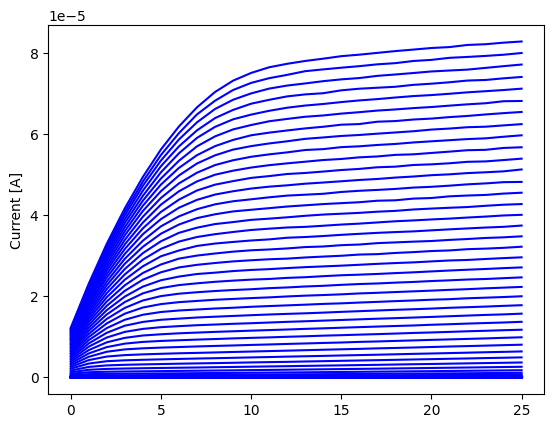

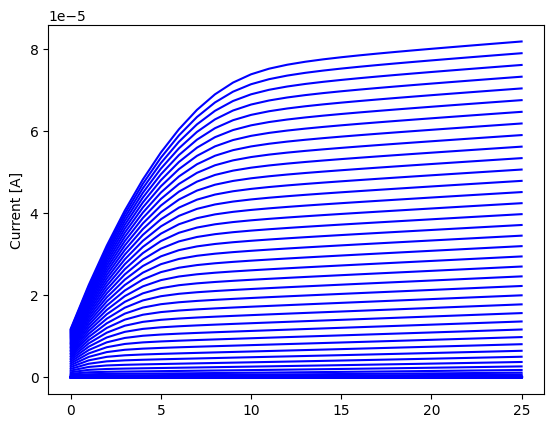

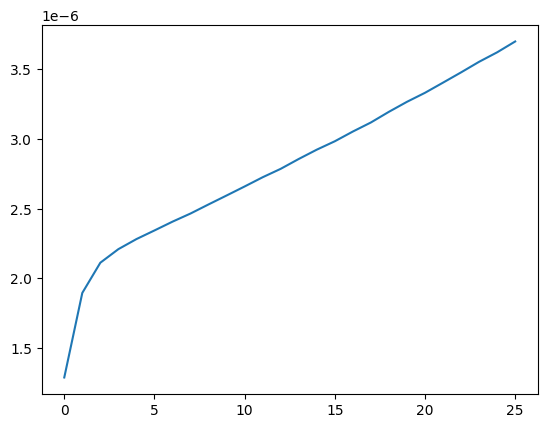

8.2876264e-05


In [7]:
encoder.eval()
decoder.eval()

data_for_encoder = torch_dataset[0]
data_for_encoder = torch.tensor(data_for_encoder, dtype=torch.float32)
data_for_encoder = data_for_encoder.to(device)
# data_for_encoder = torch.zeros_like(data_for_encoder, dtype=torch.float32)
print(data_for_encoder)

with torch.no_grad():
    encoded_data = encoder(data_for_encoder)
    decoded_data = decoder(encoded_data)

decoded_data = decoded_data.cpu().numpy()
separated_curves = get_seperated_curves(decoded_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
separated_curves_1 = get_seperated_curves(data_for_encoder.cpu().numpy(), VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves_1)

plt.plot(separated_curves[20])
plt.show()
print(np.max(decoded_data))

In [8]:
VALIDATION_CSV_FILE = "nmos_130nm_gaussian_l_vth_rds_100_devs_into_subth_VALIDATION.csv"
validation_dataframe = pd.read_csv(VALIDATION_CSV_FILE, sep=SEP, header=None)

validation_dataset = TorchDataset(
    validation_dataframe,
    CURRENT_COL,
    DEVICE_DIM
)


for i in range(len(validation_dataset)):
    print(validation_dataset[i])

[2.010414e-11 4.356364e-11 9.431862e-11 ... 9.910068e-05 1.025550e-04
 1.060066e-04]
[8.713669e-11 1.882917e-10 4.052560e-10 ... 1.063434e-04 1.098110e-04
 1.132733e-04]
[4.016465e-11 8.702179e-11 1.881321e-10 ... 1.009900e-04 1.042965e-04
 1.075971e-04]
[1.823833e-10 3.930354e-10 8.422992e-10 ... 1.080719e-04 1.113614e-04
 1.146429e-04]
[9.136332e-12 1.975591e-11 4.278363e-11 ... 8.496168e-05 8.798059e-05
 9.099677e-05]
[1.255617e-10 2.710038e-10 5.821490e-10 ... 1.053856e-04 1.086829e-04
 1.119732e-04]
[8.164262e-13 1.375080e-12 3.504245e-12 ... 7.100893e-05 7.388439e-05
 7.676264e-05]
[6.757251e-12 1.458352e-11 3.156248e-11 ... 8.271274e-05 8.574919e-05
 8.878478e-05]
[2.381473e-09 4.997408e-09 1.033441e-08 ... 1.434283e-04 1.475130e-04
 1.515890e-04]
[5.480478e-12 1.181251e-11 2.556151e-11 ... 8.006344e-05 8.295024e-05
 8.583453e-05]
[3.302460e-12 7.072326e-12 1.526239e-11 ... 7.592644e-05 7.882214e-05
 8.171856e-05]
[4.865910e-11 1.053089e-10 2.272725e-10 ... 9.715817e-05 1.003732

In [9]:
# torch.save(encoder, "encoder_full_model.pth")
# torch.save(decoder, "decoder_full_model.pth")

In [10]:
TIMESTEPS = 60
EPOCHS = 30_000
mlp_model = Mlp(TIMESTEPS).to(device)
diffusion_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=LEARNING_RATE
)

betas = (torch.sigmoid(torch.linspace(-18, 10, TIMESTEPS)) * (3e-1 - 1e-5) + 1e-5)
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, dim=0)
first_device_data_tensor = first_device_data_tensor.to(device)

tensor(0.0214, device='cuda:0')
tensor(1.0086, device='cuda:0')


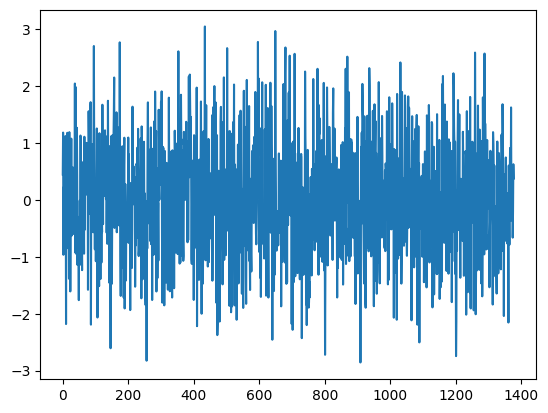

In [11]:
# check mean and var of noised data
from src.forward_process import forward_process
_, _, noise = forward_process(
    TIMESTEPS,
    alphas_bar,
    first_device_data_tensor,
    betas,
    alphas
)

mean = noise.mean(0)
std = noise.std(0)

print(mean)
print(std)
plt.plot(noise.cpu().numpy())

In [12]:
max_val = np.max(torch_dataset.data)
min_val = np.min(torch_dataset.data)

In [113]:
EPOCHS = 5_000

In [13]:
pretrain_latent_diffusion(mlp_model, encoder, first_device_data_tensor, diffusion_optimizer, EPOCHS, betas, alphas, alphas_bar, TIMESTEPS, logger, device, train_loader, min_val, max_val, decoder)

 66%|██████▌   | 19742/30000 [18:23<09:33, 17.89it/s]  


KeyboardInterrupt: 

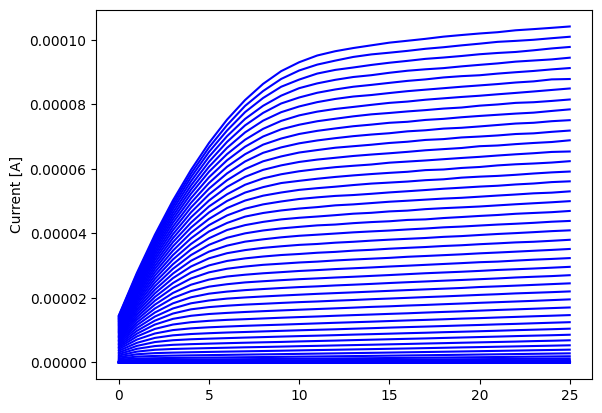

In [41]:
mlp_model.eval()

out_tensor = visualize_0(
    first_device_data_tensor.reshape(1, -1),
    alphas_bar,
    betas,
    alphas,
    TIMESTEPS,
    mlp_model,
    encoder,
    decoder,
    device
)

out_numpy_data = out_tensor.cpu().numpy()
out_numpy_data = out_numpy_data.squeeze(0)
separated_curves = get_seperated_curves(out_numpy_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)

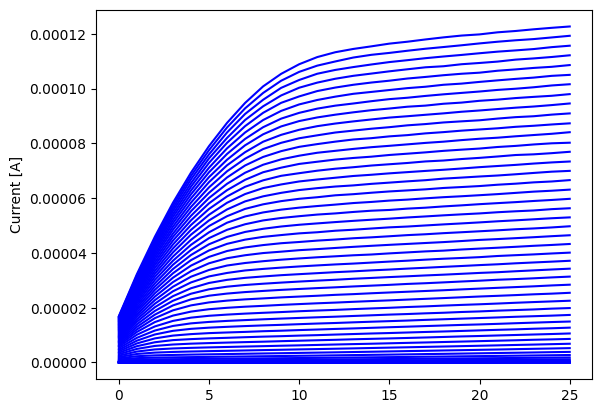

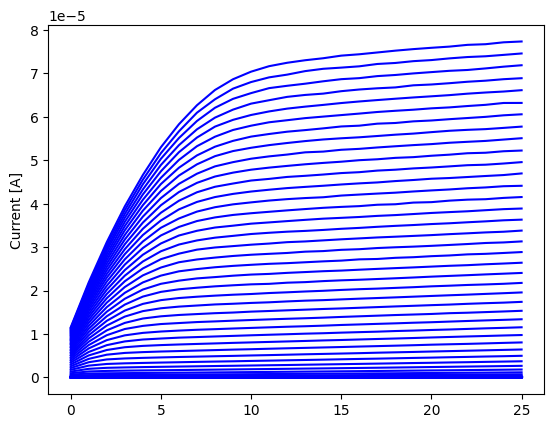

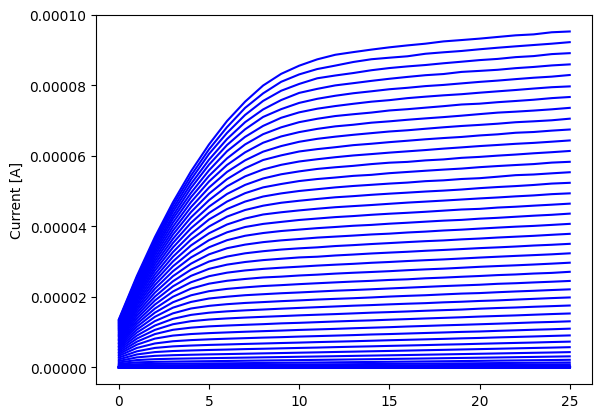

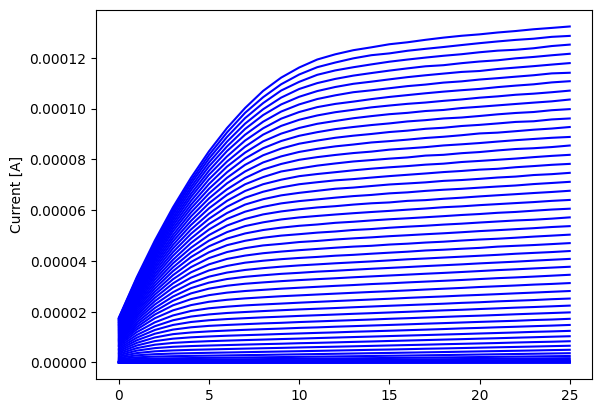

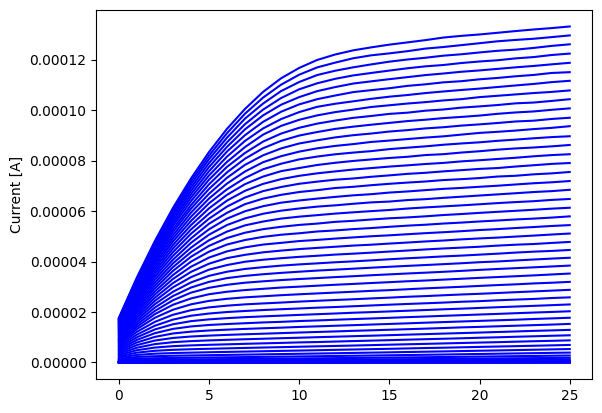

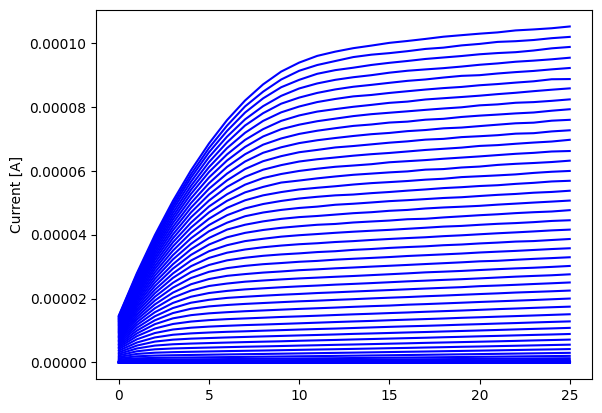

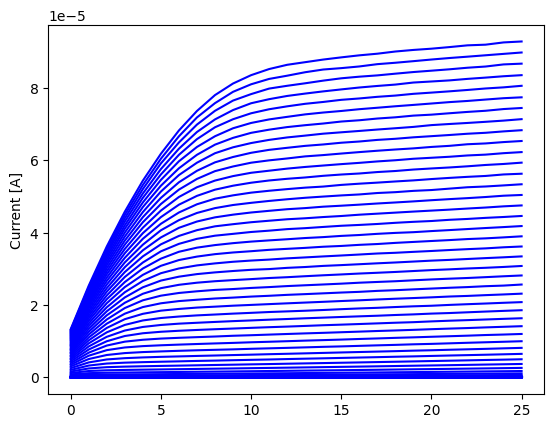

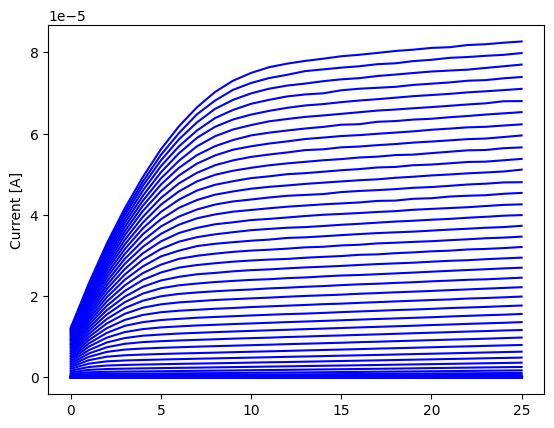

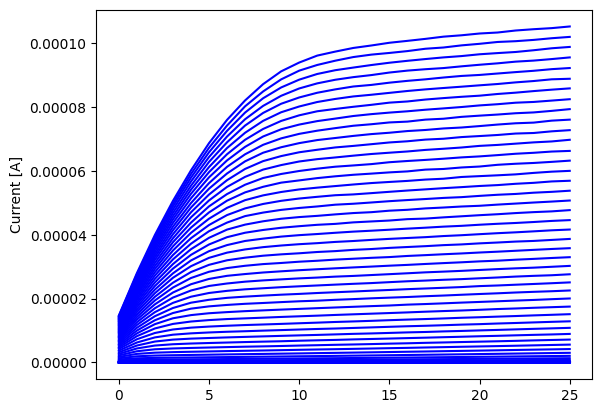

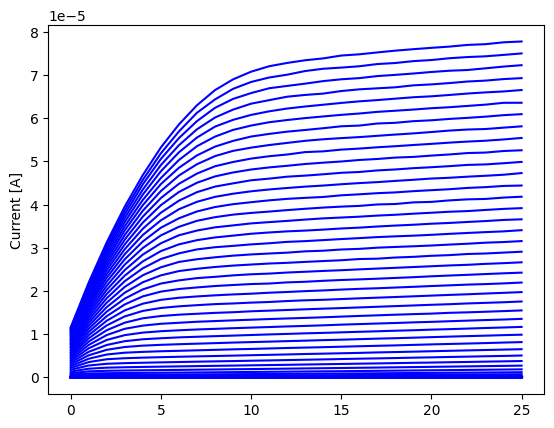

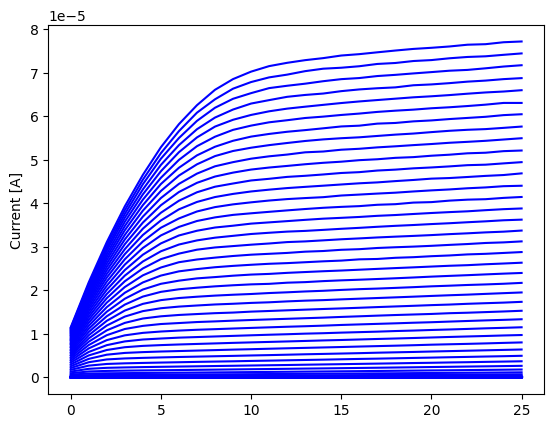

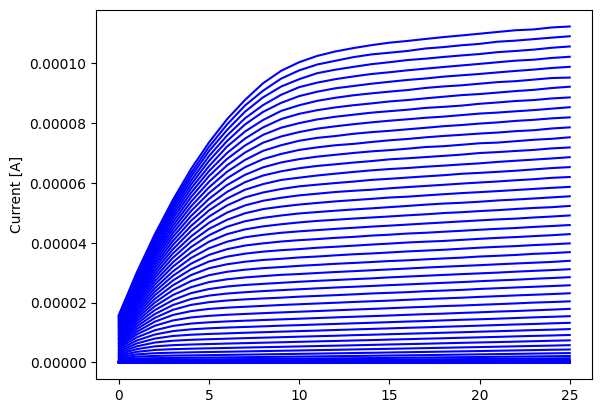

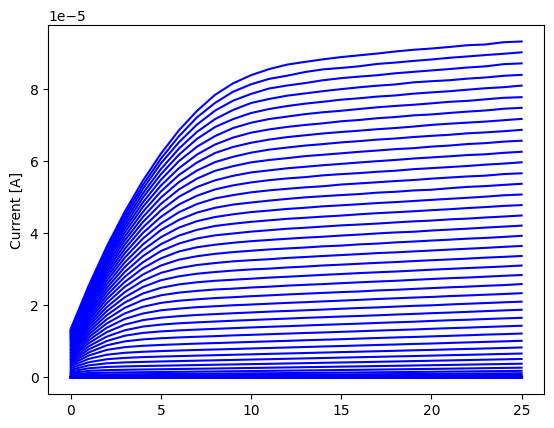

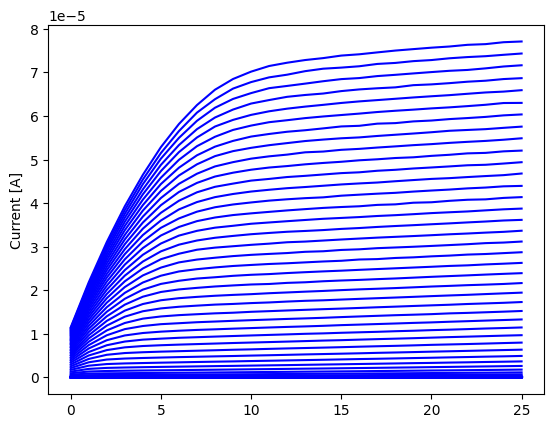

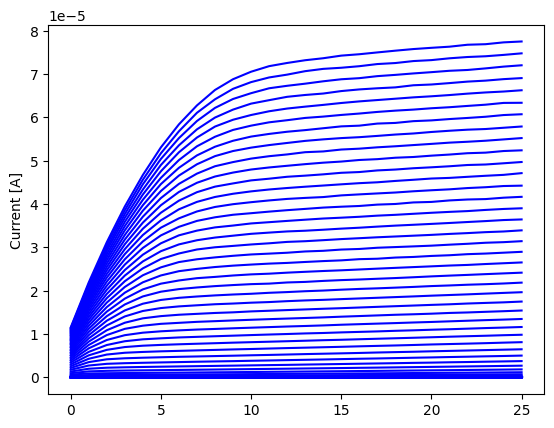

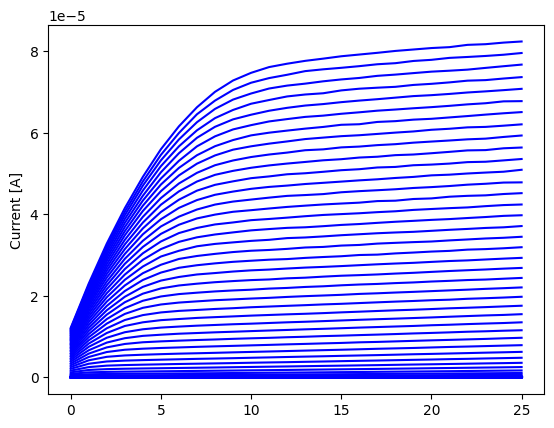

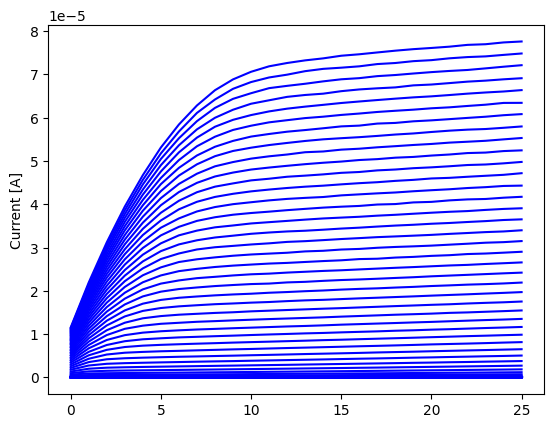

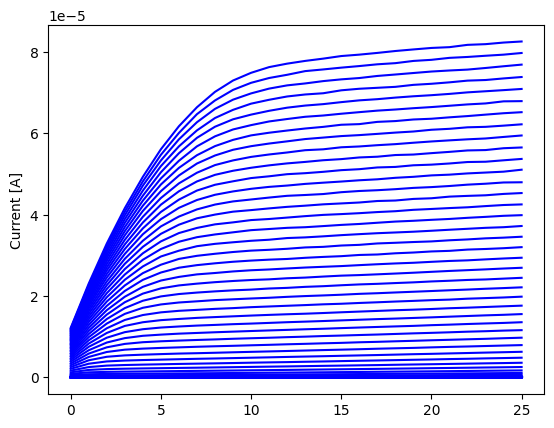

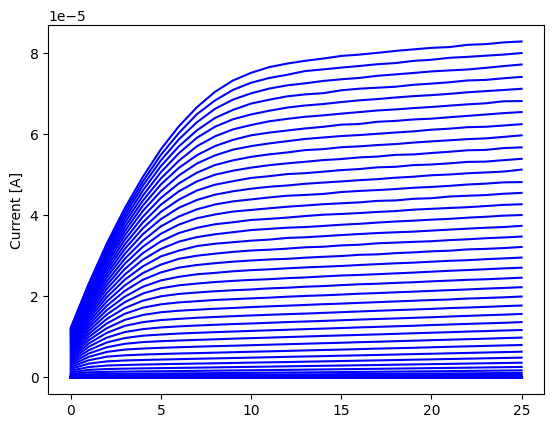

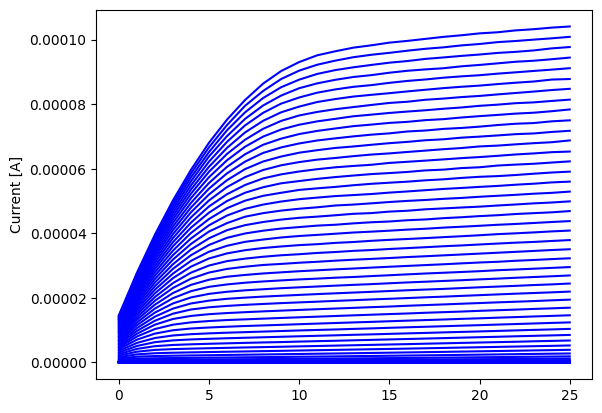

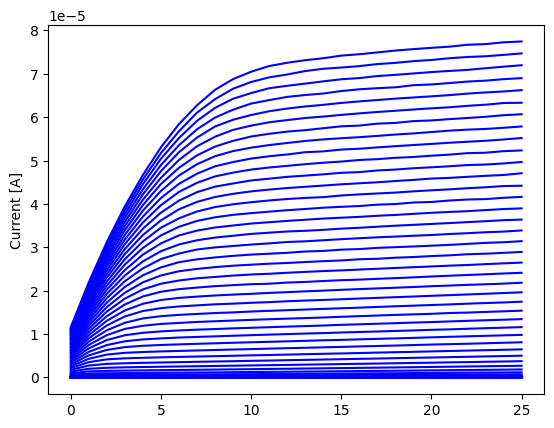

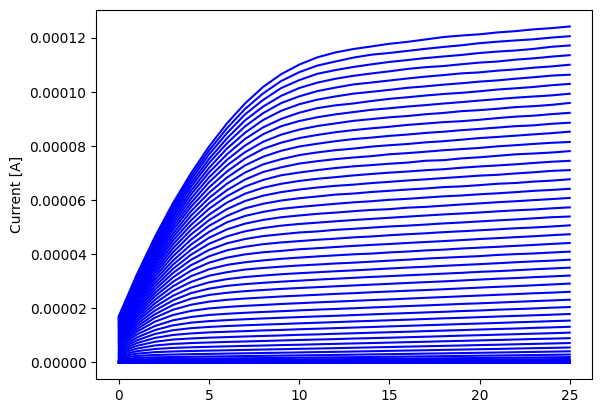

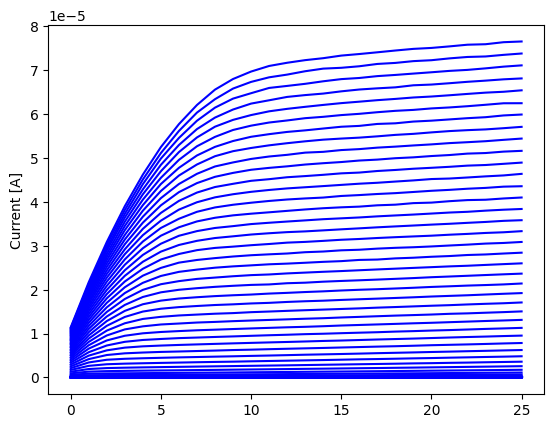

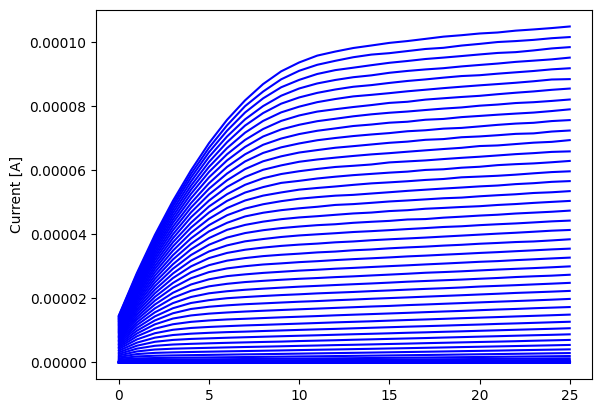

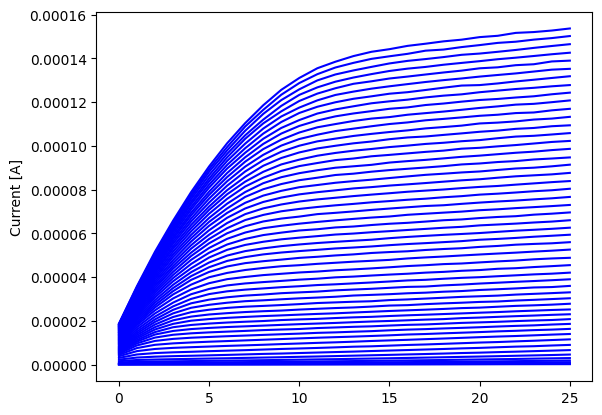

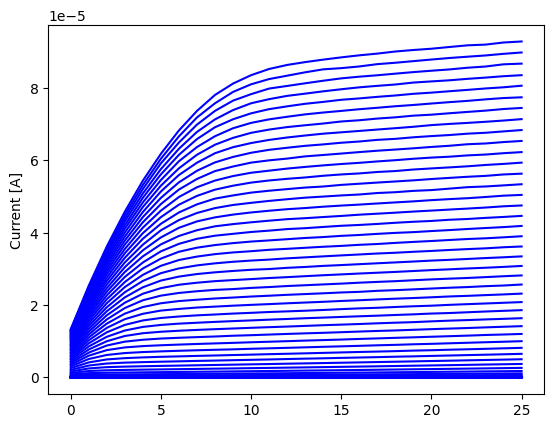

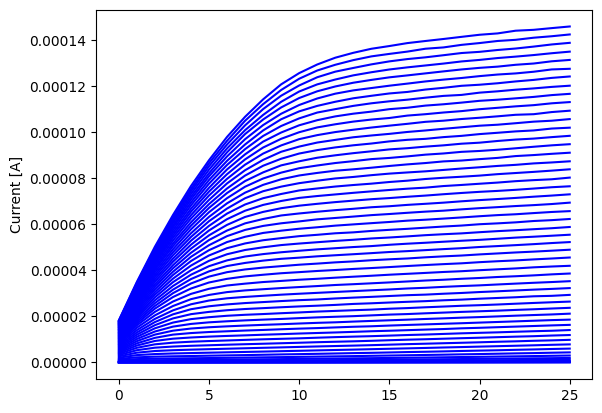

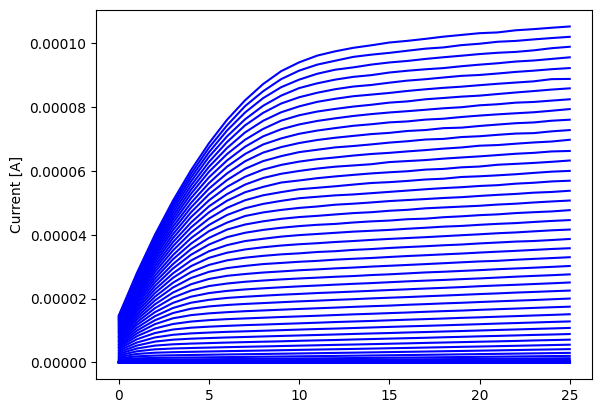

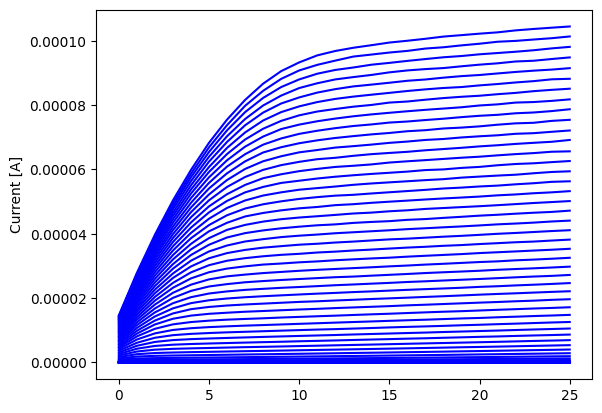

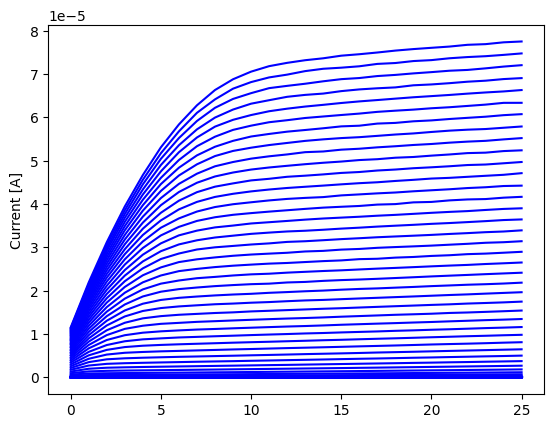

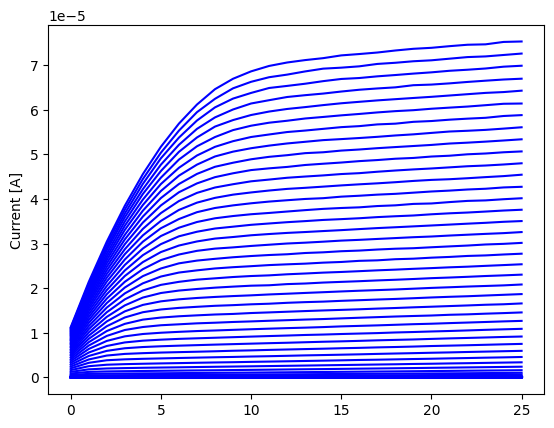

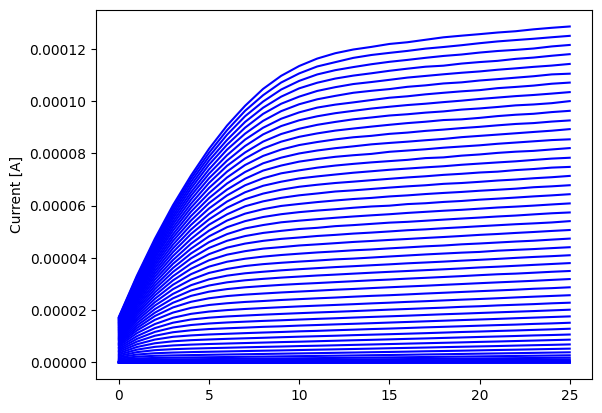

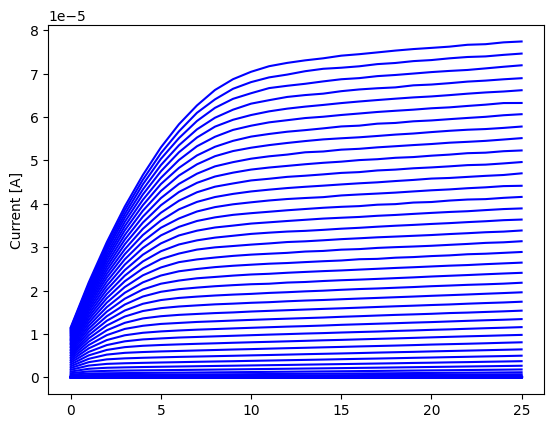

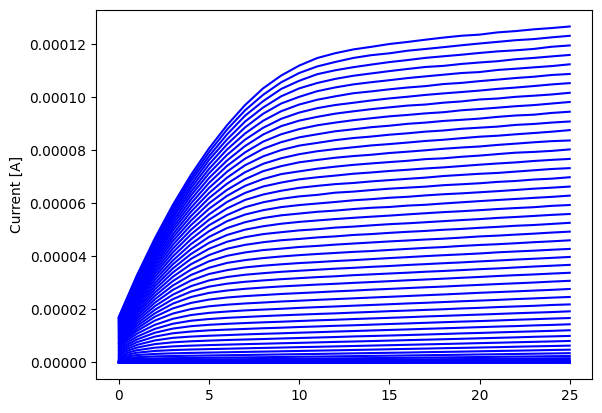

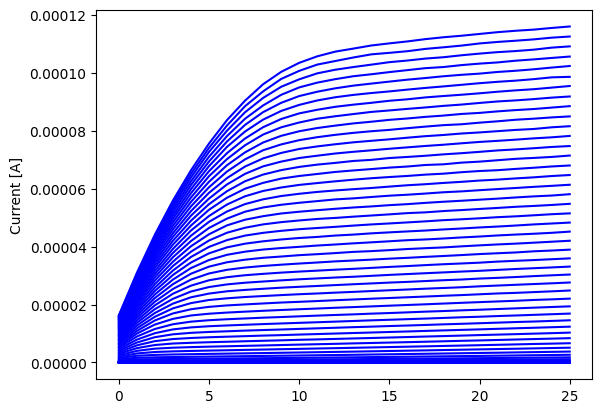

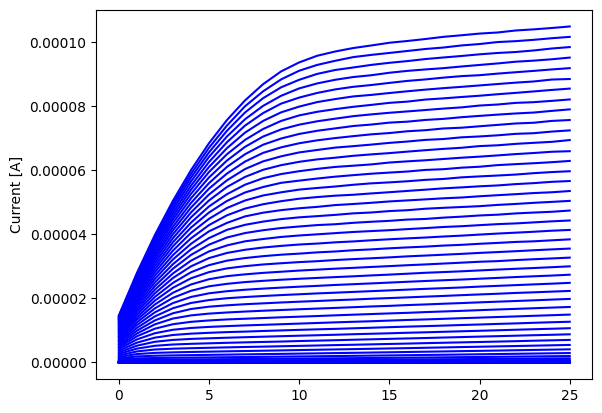

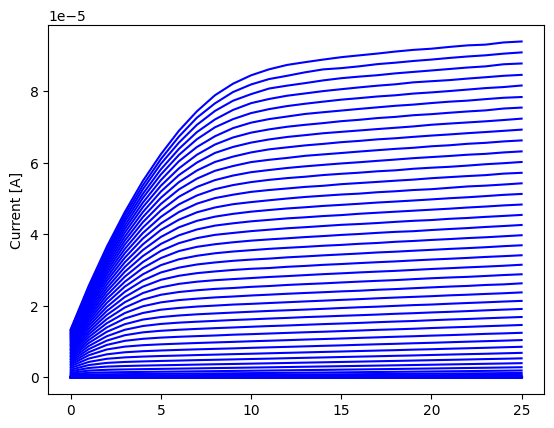

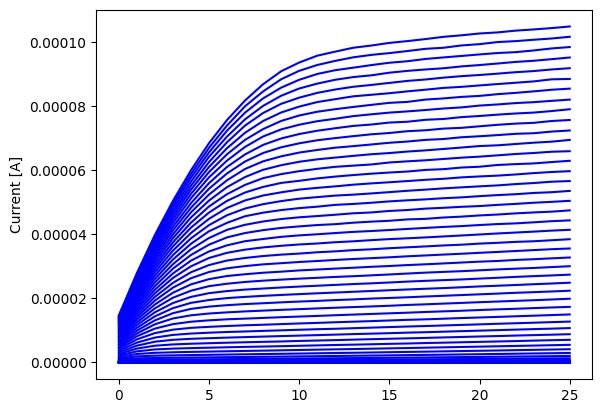

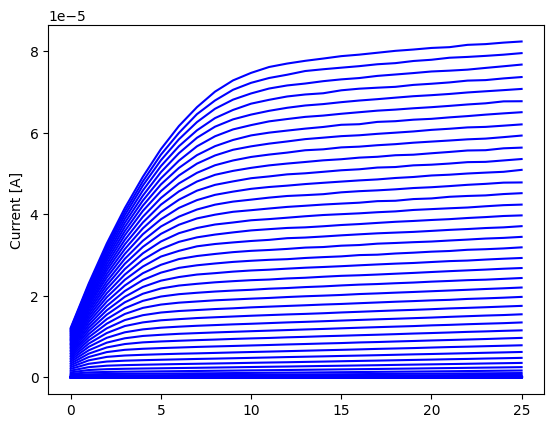

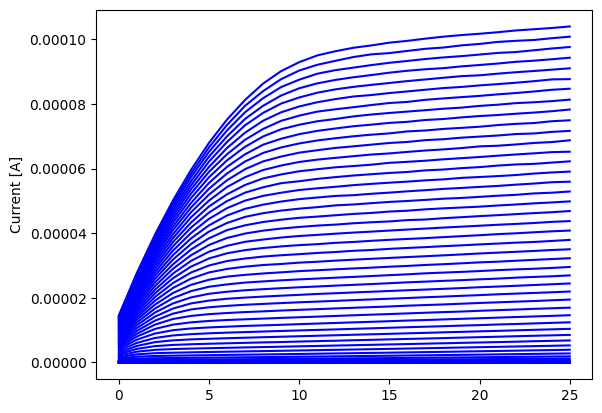

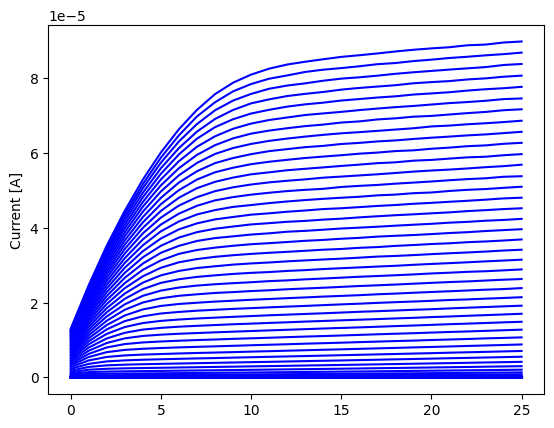

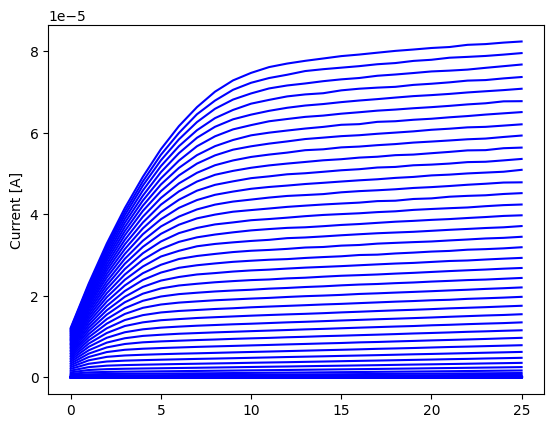

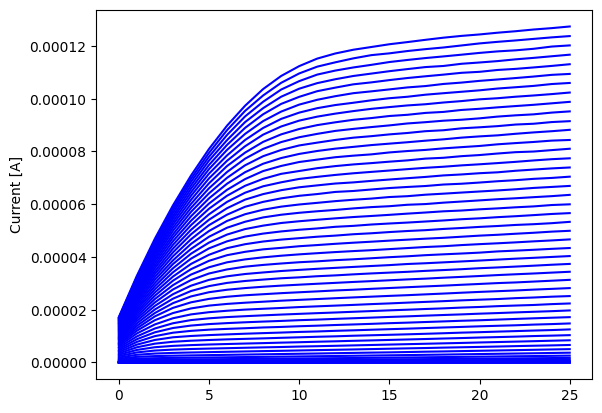

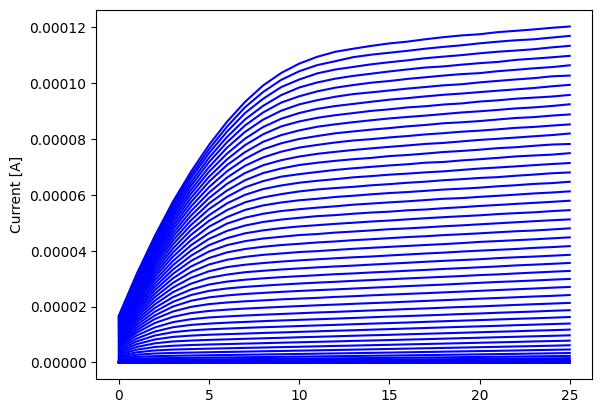

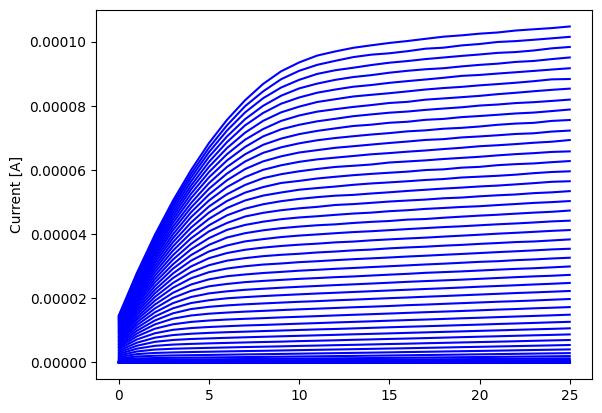

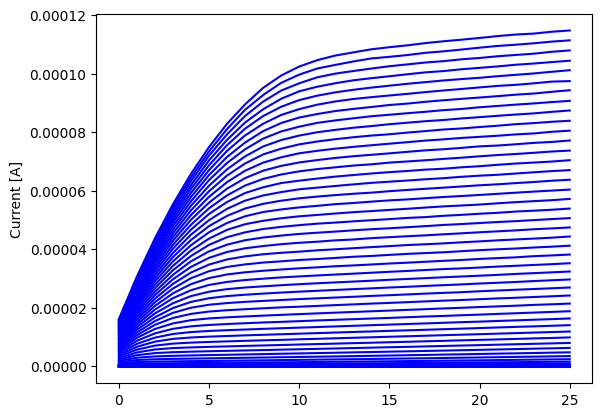

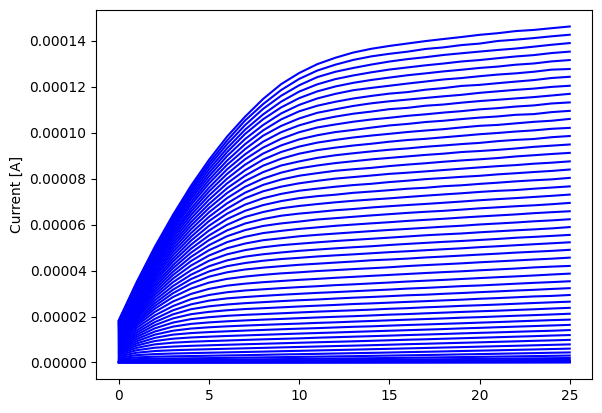

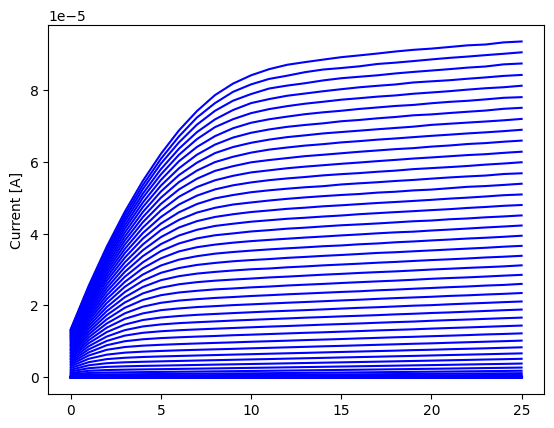

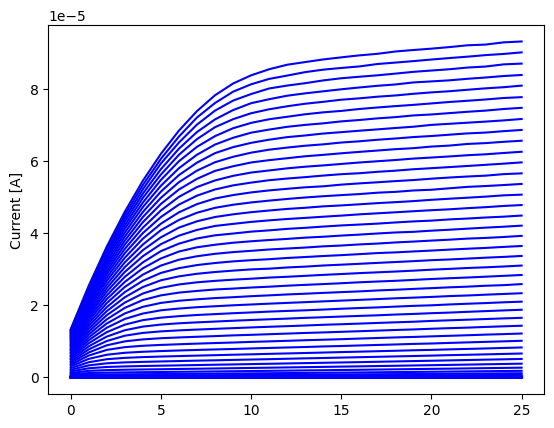

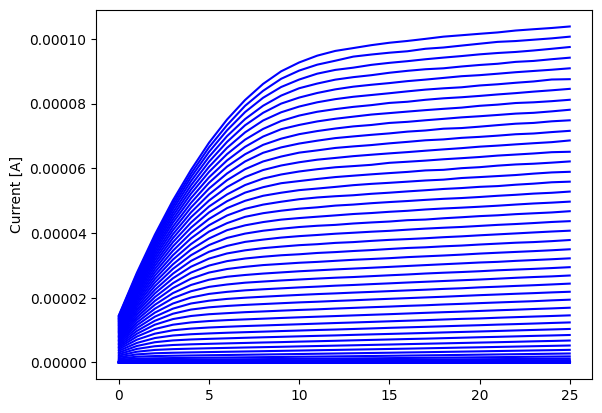

In [16]:
# plot data for all 50 device cases
array_with_outputs = []
for index in range(len(torch_dataset)):
    dev_data = torch_dataset[index]
    dev_data = torch.tensor(dev_data, dtype=torch.float32, device=device).reshape(1, -1)

    out_tensor = visualize_0(
        dev_data,
        alphas_bar,
        betas,
        alphas,
        TIMESTEPS,
        mlp_model,
        encoder,
        decoder,
        device
    )
    out_numpy_data = out_tensor.cpu().numpy()
    out_numpy_data = out_numpy_data.squeeze(0)
    array_with_outputs.append(out_numpy_data)

for index in range(len(array_with_outputs)):
    out_numpy_data = array_with_outputs[index]
    separated_curves = get_seperated_curves(out_numpy_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
    plot_curves(separated_curves)

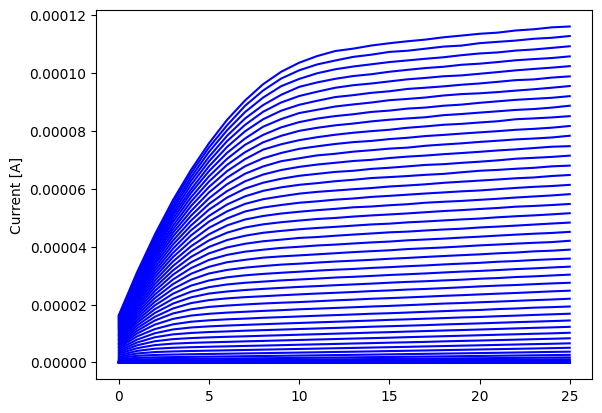

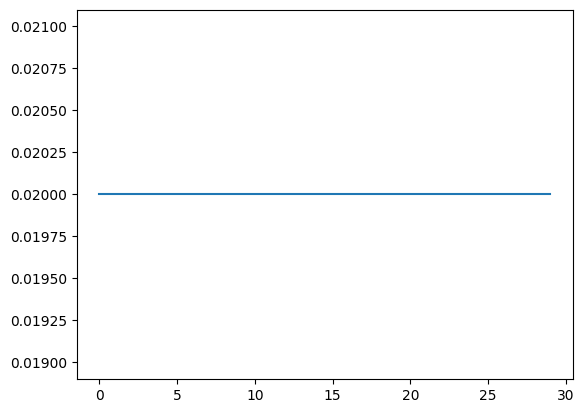

In [48]:
with torch.no_grad():
    test_data = torch.ones(30, dtype=torch.float32, device=device) * 0.02
    decoder_result = decoder(test_data)

decoder_result = decoder_result.cpu().numpy()

separated_curves = get_seperated_curves(decoder_result, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)

plt.show()
plt.plot(test_data.cpu().numpy())